In [1]:
import sys 
sys.path.insert(
    0,
    "/raid0/homes/jkitzmann/dev/ITK-build-binarythinning/Wrapping/Generators/Python"
)
import itk

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Typesystem Boilerplate and Helper Functions

In [3]:
PixelType = itk.UC
Dimension = 3
ImageType = itk.Image[PixelType, Dimension]
LabelPixelType = itk.SS
LabelImageType = itk.Image[LabelPixelType, Dimension]
TubeType = itk.TubeSpatialObject[Dimension]
TubePointType = itk.TubeSpatialObjectPoint[Dimension]
PointSetType = itk.PointSet[itk.D, Dimension]

In [4]:
PixelType = itk.UC
Dimension = 3
ImageType = itk.Image[PixelType, Dimension]
FloatImageType = itk.Image[itk.F, Dimension]

def _to_xyz_list(points):
    """Normalize show_points into a list of (x, y, z) tuples.

    Accepts a single ITK index (or (x, y, z) sequence), or a list of them.
    """
    if points is None:
        return []

    # a bare (x, y, z) is one point; a list/tuple of those is many
    if not (isinstance(points, (list, tuple)) and not np.isscalar(points[0])):
        points = [points]

    return [(int(p[0]), int(p[1]), int(p[2])) for p in points]

def show_mip(image, show_points=None, cmap="gray"):
    ar = itk.array_view_from_image(image)

    points = _to_xyz_list(show_points)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(np.max(ar, axis=0), cmap=cmap)
    axes[0].set_title("Axial MIP")
    axes[0].axis("off")

    axes[1].imshow(np.max(ar, axis=1), cmap=cmap)
    axes[1].set_title("Coronal MIP")
    axes[1].axis("off")

    axes[2].imshow(np.max(ar, axis=2), cmap=cmap)
    axes[2].set_title("Sagittal MIP")
    axes[2].axis("off")

    # add points from list
    for ax, (col, row) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
        ax.autoscale(False)
        for point in points:
            ax.scatter(
                point[col],
                point[row],
                s=80,
                facecolors="none",
                edgecolors="red",
                linewidths=1.5,
            )

    plt.tight_layout()
    plt.show()

## Synthetic Airway

In [5]:
import os

nifti_dir = "synthetic_nifti"  # written by `python SyntheticAirway.py`

def load_synthetic_airway(generations):
    path = os.path.join(nifti_dir, f"synthetic_airway_gen{generations:02d}.nii.gz")
    return itk.imread(path, pixel_type=PixelType)

def shift_mask(image, shift):
    """Translate a mask by whole voxels (same axis order as SyntheticTube
    centerlines), zero-filling instead of wrapping."""
    array = itk.array_from_image(image)
    shifted = np.zeros_like(array)
    src = tuple(slice(max(0, -s), n - max(0, s)) for s, n in zip(shift, array.shape))
    dst = tuple(slice(max(0, s), n + min(0, s)) for s, n in zip(shift, array.shape))
    shifted[dst] = array[src]
    output = itk.image_from_array(shifted)
    output.CopyInformation(image)
    return output

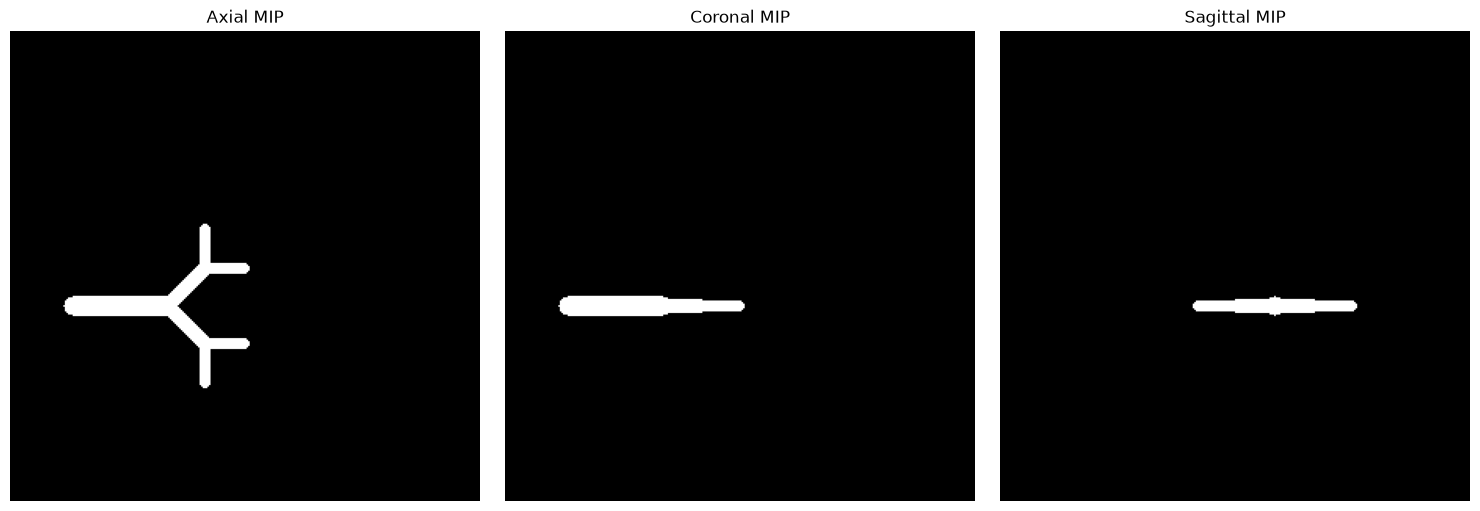

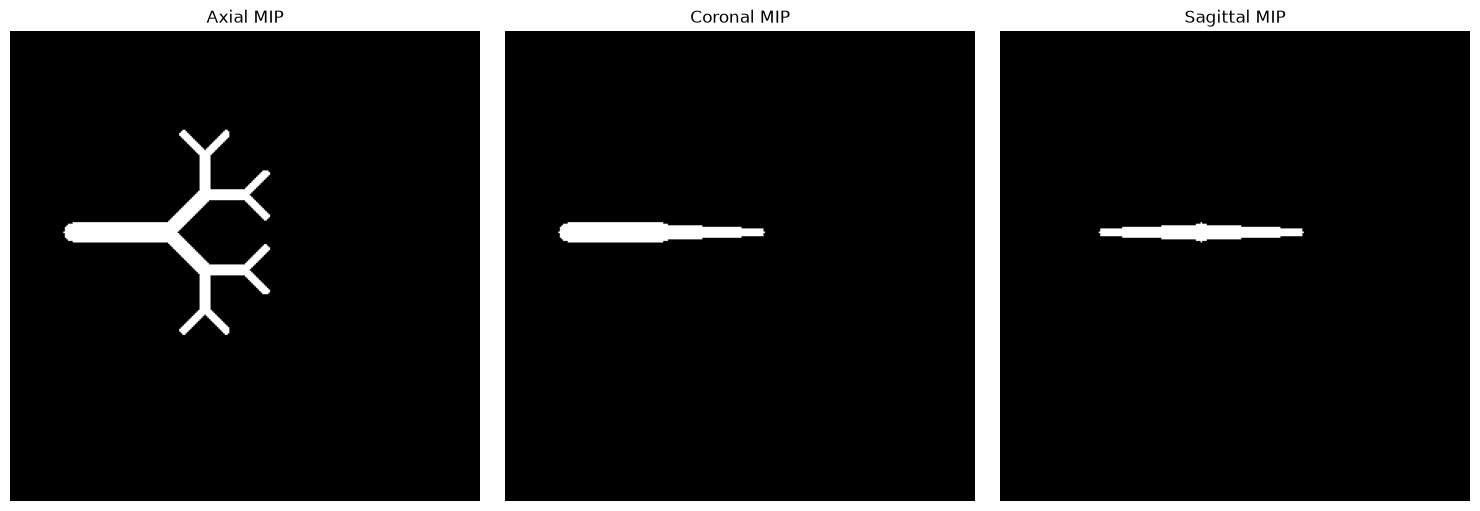

In [6]:
fixed_generations = 4
moving_generations = 3
moving_shift = (47, 47, 0)

fixed_mask = load_synthetic_airway(fixed_generations)
moving_mask = shift_mask(load_synthetic_airway(moving_generations), moving_shift)

moving_image = moving_mask
fixed_image = fixed_mask

show_mip(moving_image)
show_mip(fixed_image)

## Deformable Registration and Analysis Pipeline

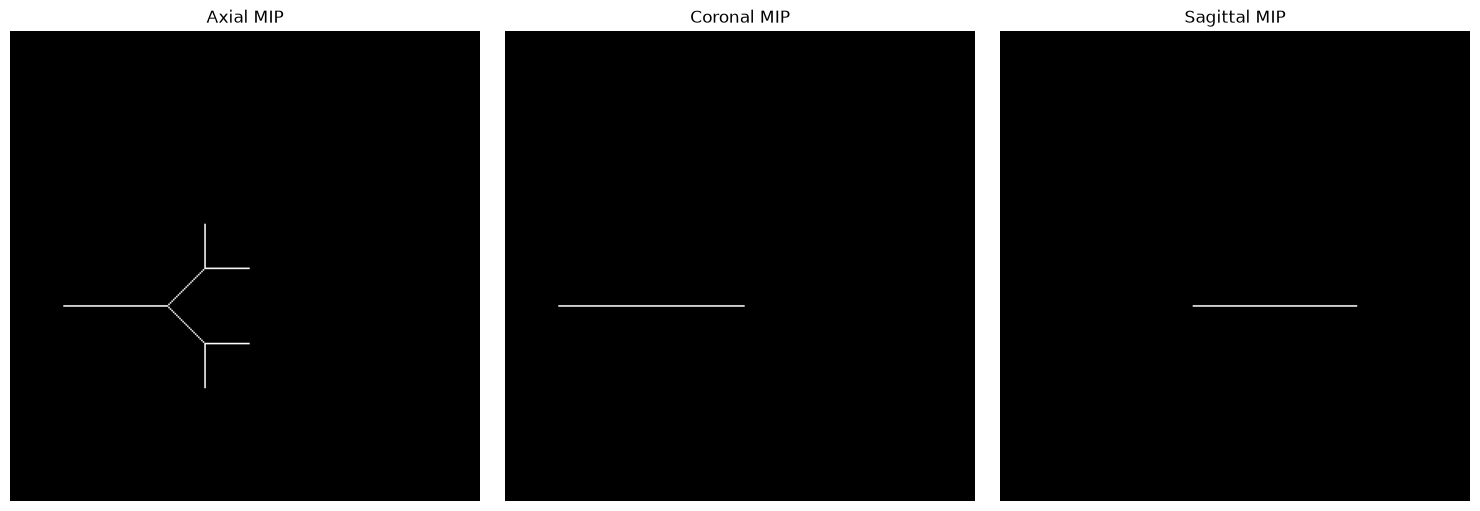

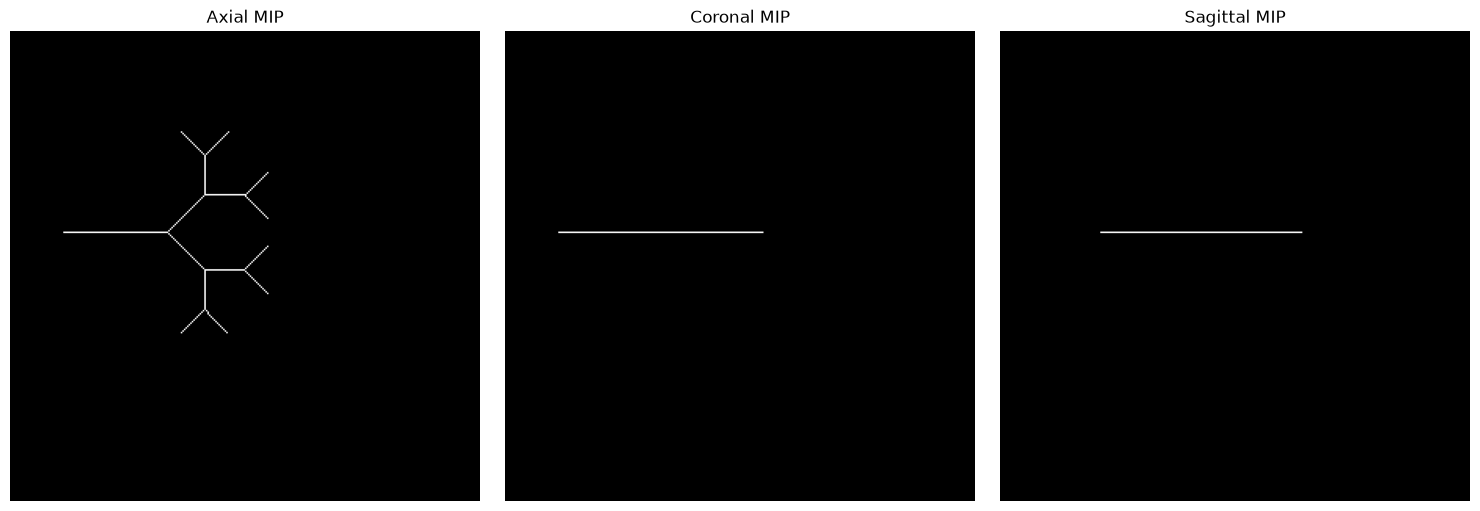

In [7]:
SkeletonizeAirwayType = itk.SkeletonizeAirway[ImageType]

skeletonizeAirwayPrediction = SkeletonizeAirwayType.New()
skeletonizeAirwayPrediction.SetInput(moving_image)
skeletonizeAirwayPrediction.Update()
moving_skeleton = skeletonizeAirwayPrediction.GetOutput()
show_mip(moving_skeleton)

skeletonizeAirwayGroundTruth = SkeletonizeAirwayType.New()
skeletonizeAirwayGroundTruth.SetInput(fixed_image)
skeletonizeAirwayGroundTruth.Update()
fixed_skeleton = skeletonizeAirwayGroundTruth.GetOutput()
show_mip(fixed_skeleton)

## Initial Labeling

widest index: [40, 175, 175]


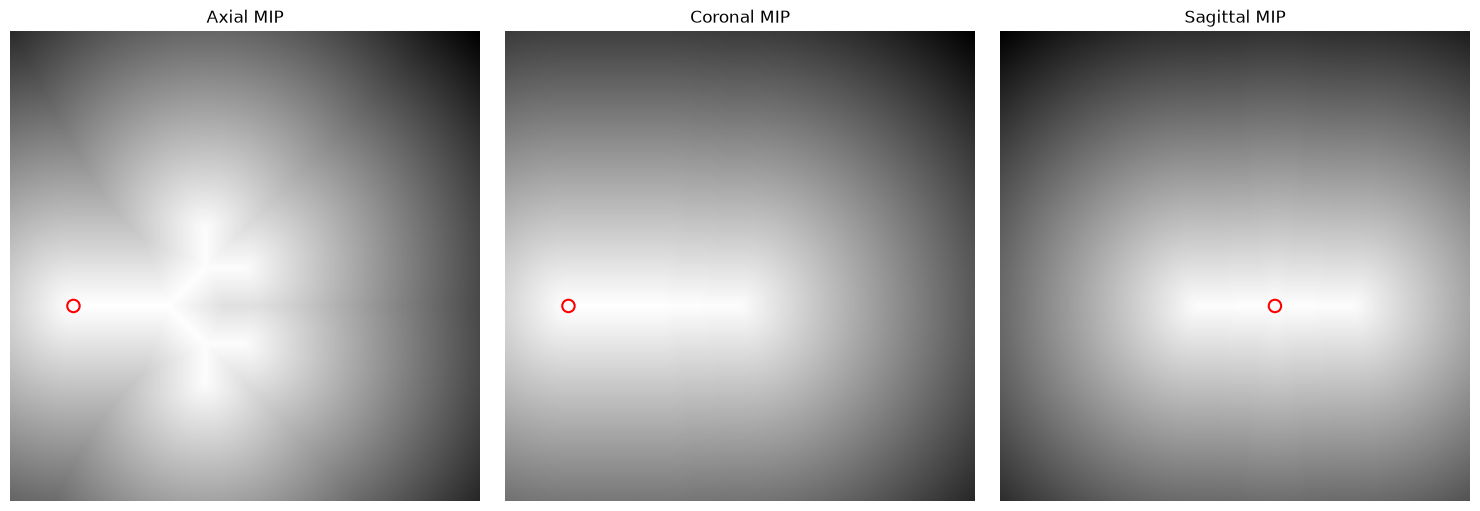

widest index: [40, 128, 128]


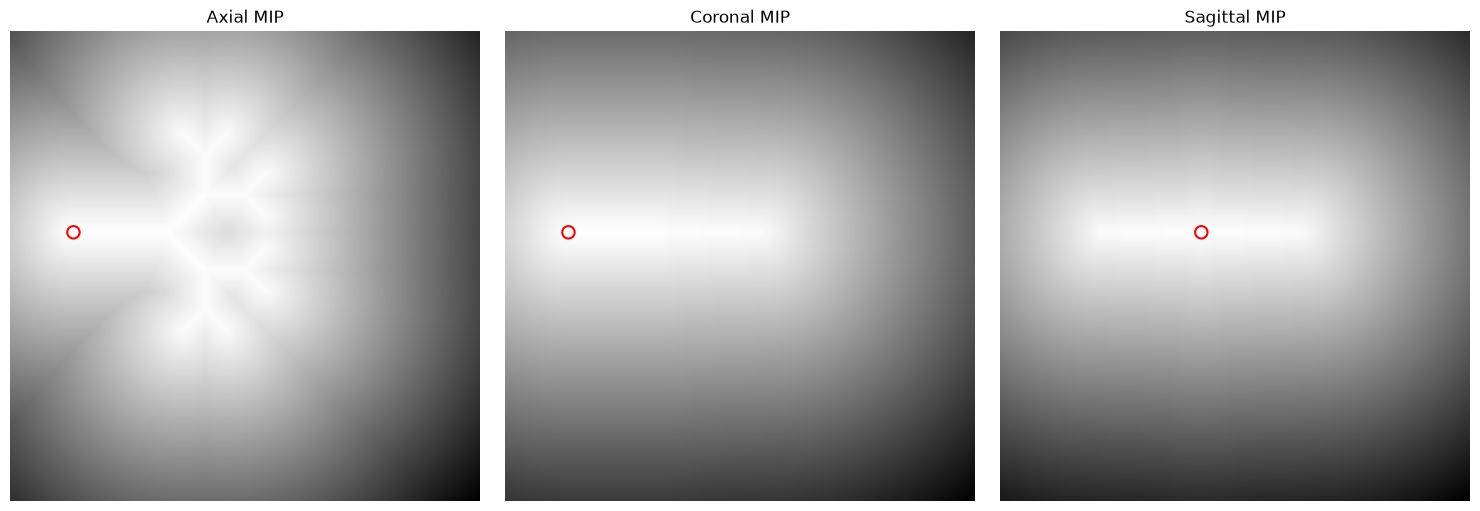

In [8]:
LabelPixelType = itk.SS
LabelImageType = itk.Image[LabelPixelType, Dimension]

SkeletonLabelingType = itk.SkeletonLabeling[ImageType, LabelImageType]

skeletonLabelingPrediction = SkeletonLabelingType.New()
skeletonLabelingPrediction.SetMaskImage(moving_image)
skeletonLabelingPrediction.SetSkeletonImage(moving_skeleton)
skeletonLabelingPrediction.SetMinimumLandmarkDistance(5.0)
skeletonLabelingPrediction.SetSensitivityMultiplier(1.0)
skeletonLabelingPrediction.Update()
branchLabelsImagePrediction = skeletonLabelingPrediction.GetBranchLabelsImage()
generationLabelsImagePrediction = skeletonLabelingPrediction.GetGenerationLabelsImage()
distanceMapImagePrediction = skeletonLabelingPrediction.GetDistanceMapImage()
widestIndexPrediction = skeletonLabelingPrediction.GetWidestIndex()

print("widest index:", list(widestIndexPrediction))
show_mip(distanceMapImagePrediction, show_points=widestIndexPrediction)

skeletonLabelingGroundTruth = SkeletonLabelingType.New()
skeletonLabelingGroundTruth.SetMaskImage(fixed_image)
skeletonLabelingGroundTruth.SetSkeletonImage(fixed_skeleton)
skeletonLabelingGroundTruth.SetSensitivityMultiplier(1.0)
skeletonLabelingGroundTruth.SetMinimumLandmarkDistance(5.0)
skeletonLabelingGroundTruth.Update()
branchLabelsImageGroundTruth = skeletonLabelingGroundTruth.GetBranchLabelsImage()
generationLabelsImageGroundTruth = skeletonLabelingGroundTruth.GetGenerationLabelsImage()
distanceMapImageGroundTruth = skeletonLabelingGroundTruth.GetDistanceMapImage()
widestIndexGroundTruth = skeletonLabelingGroundTruth.GetWidestIndex()

print("widest index:", list(widestIndexGroundTruth))
show_mip(distanceMapImageGroundTruth, show_points=widestIndexGroundTruth)

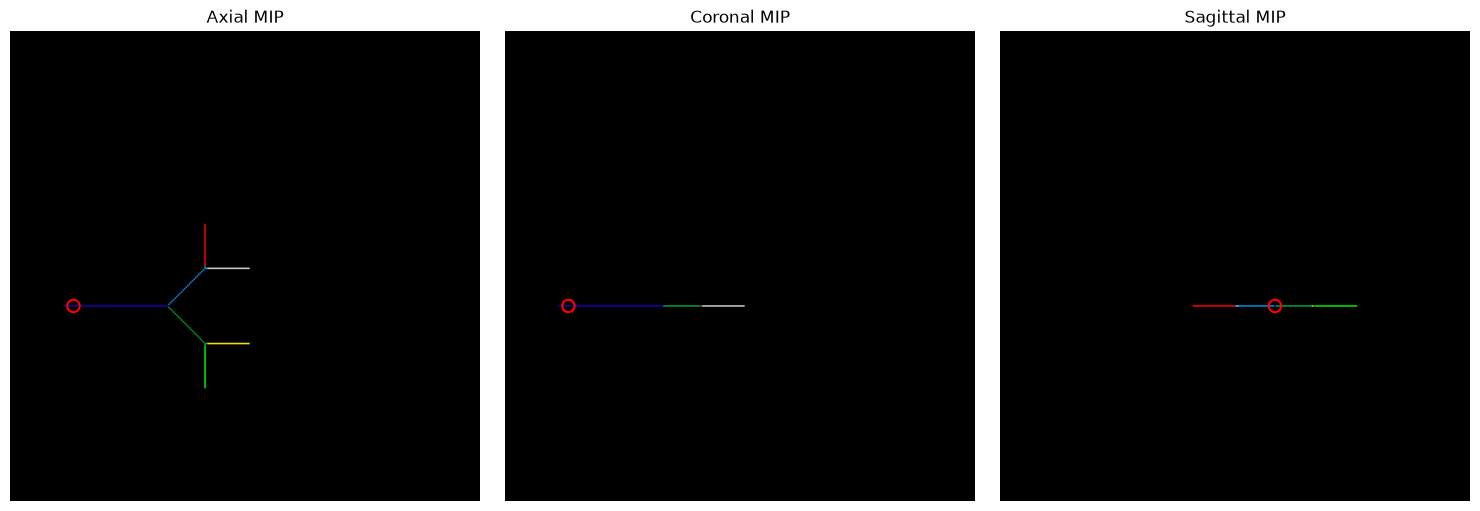

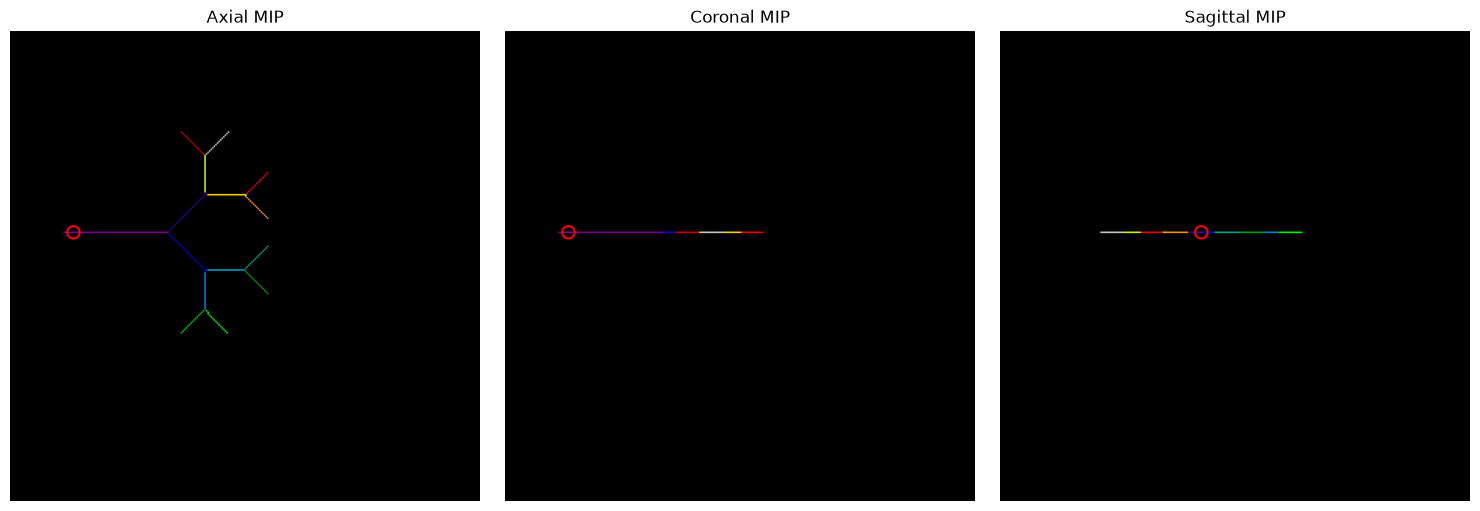

In [9]:
branch_labels_prediction = itk.array_view_from_image(branchLabelsImagePrediction)
show_mip(branchLabelsImagePrediction, show_points=widestIndexPrediction, cmap="nipy_spectral")

branch_labels_groundTruth = itk.array_view_from_image(branchLabelsImageGroundTruth)
show_mip(branchLabelsImageGroundTruth, show_points=widestIndexGroundTruth, cmap="nipy_spectral")


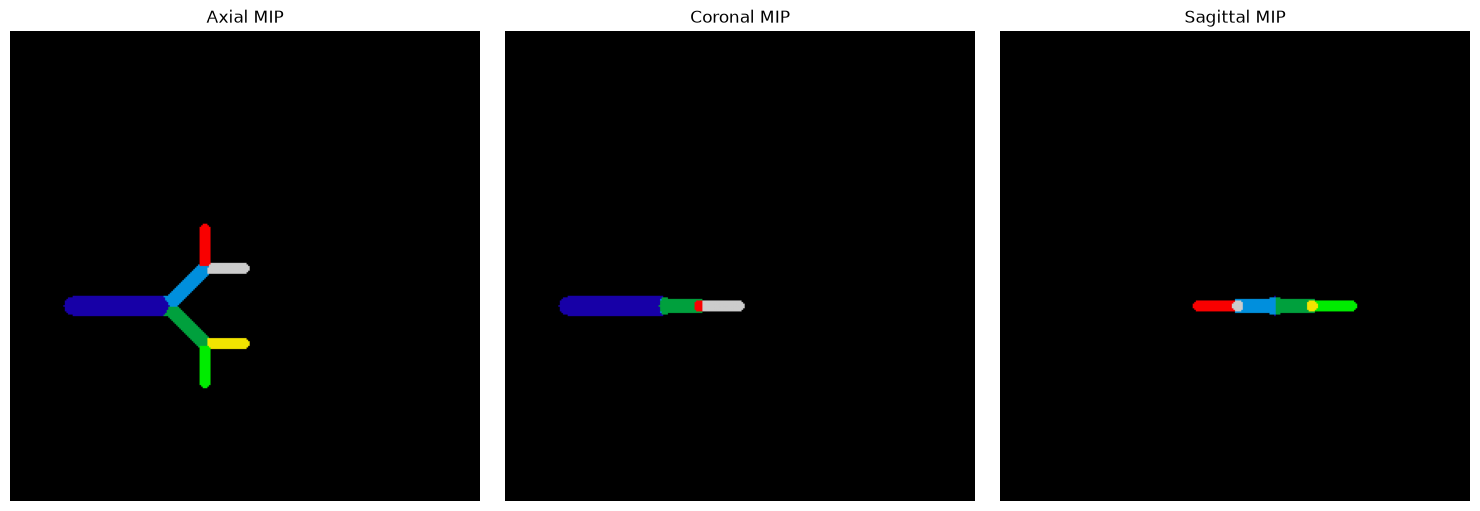

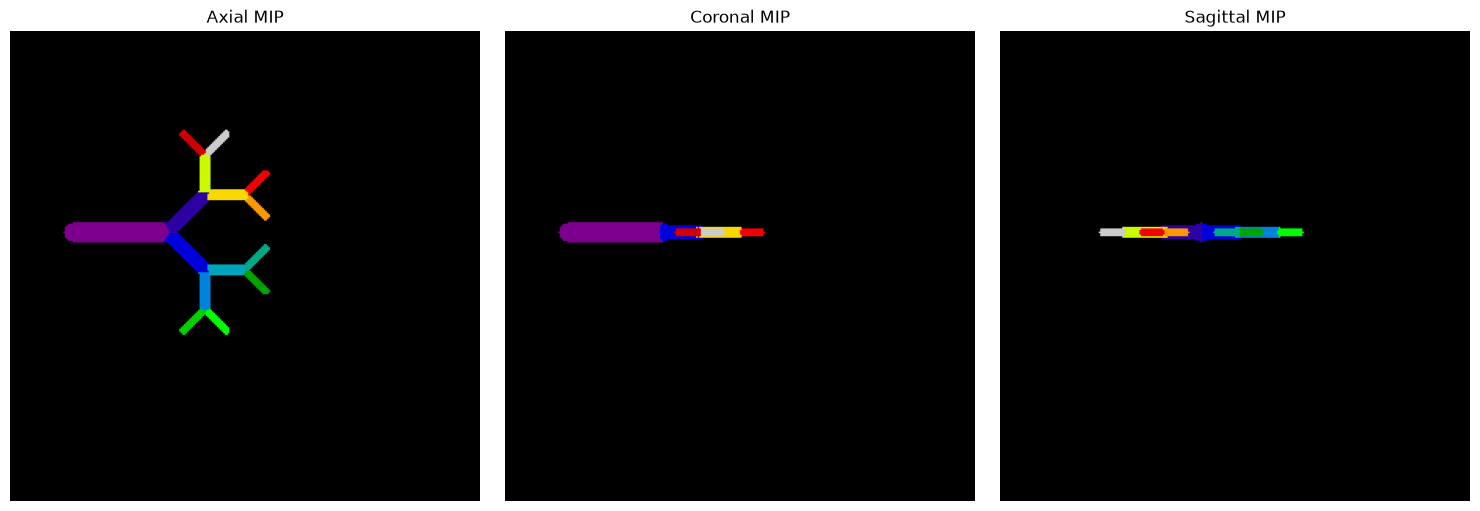

In [10]:
ProjectAirwayType = itk.ProjectAirway[ImageType, LabelImageType]

projectAirwayPrediction = ProjectAirwayType.New()
projectAirwayPrediction.SetSegmentationImage(moving_image)
projectAirwayPrediction.SetBranchSkeletonLabelsImage(branchLabelsImagePrediction)
projectAirwayPrediction.SetGenerationSkeletonLabelsImage(generationLabelsImagePrediction)
projectAirwayPrediction.SetNumberOfNeighbors(5)
projectAirwayPrediction.Update()
projectedBranchLabelsImagePrediction = projectAirwayPrediction.GetBranchLabelsImage()
show_mip(projectedBranchLabelsImagePrediction, cmap="nipy_spectral")

projectAirwayGroundTruth = ProjectAirwayType.New()
projectAirwayGroundTruth.SetSegmentationImage(fixed_image)
projectAirwayGroundTruth.SetBranchSkeletonLabelsImage(branchLabelsImageGroundTruth)
projectAirwayGroundTruth.SetGenerationSkeletonLabelsImage(generationLabelsImageGroundTruth)
projectAirwayGroundTruth.SetNumberOfNeighbors(5)
projectAirwayGroundTruth.Update()
projectedBranchLabelsImageGroundTruth = projectAirwayGroundTruth.GetBranchLabelsImage()
show_mip(projectedBranchLabelsImageGroundTruth, cmap="nipy_spectral")

moving_image = projectedBranchLabelsImagePrediction
fixed_image = projectedBranchLabelsImageGroundTruth

## Get Branch Points

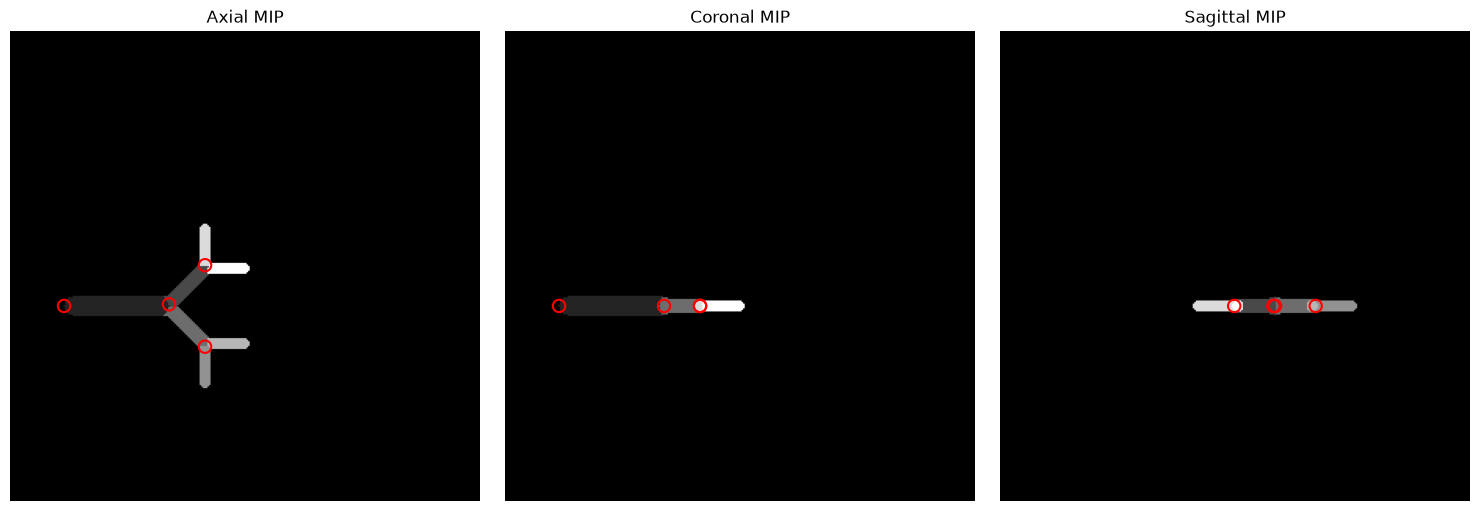

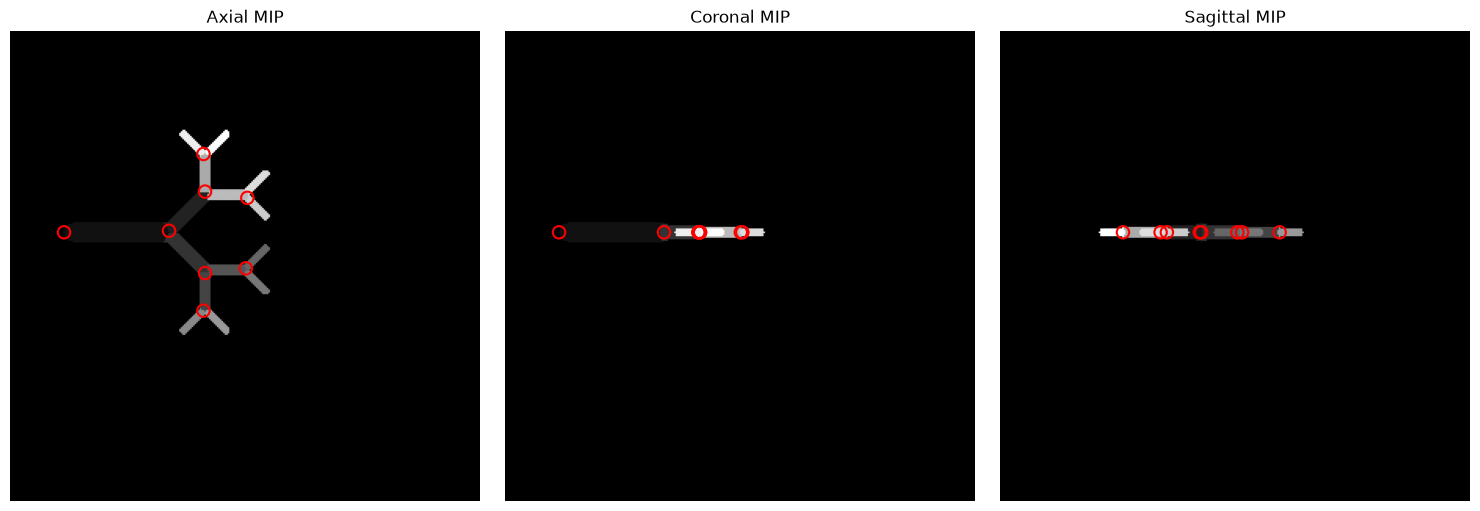

In [11]:
branch_ids_prediction = skeletonLabelingPrediction.GetLandmarks()
branch_origins_prediction = [
    skeletonLabelingPrediction.GetBranchOriginIndex(i)
    for i in branch_ids_prediction
]

branch_ids_groundTruth = skeletonLabelingGroundTruth.GetLandmarks()
branch_origins_groundTruth = [
    skeletonLabelingGroundTruth.GetBranchOriginIndex(i)
    for i in branch_ids_groundTruth
]

show_mip(moving_image, branch_origins_prediction)
show_mip(fixed_image, branch_origins_groundTruth)

In [12]:
def convert_points(point_list):
    point_set = PointSetType.New()
    point_set_points = point_set.GetPoints()
    for idx, point in enumerate(point_list):
        point_output = itk.Point[itk.D, Dimension]()
        point_output[0] = point[0]
        point_output[1] = point[1]
        point_output[2] = point[2]
        
        point_set_points.InsertElement(idx, point_output)

    return point_set

fixed_points = convert_points(branch_origins_groundTruth)
moving_points = convert_points(branch_origins_prediction)

fixed_points

<itk.itkPointSetPython.itkPointSetD3; proxy of <Swig Object of type 'itkPointSetD3 *' at 0x7fb90ec92d70> >

In [13]:
## Rigid alignment for point matching

In [14]:
RigidlyAlignAirwaysType = itk.RigidlyAlignAirways[PointSetType]
rigidlyAlignAirways = RigidlyAlignAirwaysType.New()
rigidlyAlignAirways.SetFixedPointSet(fixed_points)
rigidlyAlignAirways.SetMovingPointSet(moving_points)
rigidlyAlignAirways.Update()
transform = rigidlyAlignAirways.GetTransform()
print(transform.GetMatrix())

itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])Stop condition: LevenbergMarquardtOptimizer: Levenberg-Marquardt did not converge (iteration/tolerance limit)



vnl_least_squares_function: WARNING: unknowns(6) > residuals(4)


In [15]:
aligned = itk.resample_image_filter(
    moving_mask,
    transform=transform.GetInverseTransform(),
    use_reference_image=True,
    reference_image=fixed_image,
    interpolator = itk.NearestNeighborInterpolateImageFunction.New(moving_mask),
    default_pixel_value=0
)

In [16]:
transform = rigidlyAlignAirways.GetTransform()
aligned_points_list = []

for i in range(moving_points.GetNumberOfPoints()):
    point = moving_points.GetPoint(i)
    aligned_point = transform.TransformPoint(point)
    aligned_points_list.append(aligned_point)

aligned_points = convert_points(aligned_points_list)

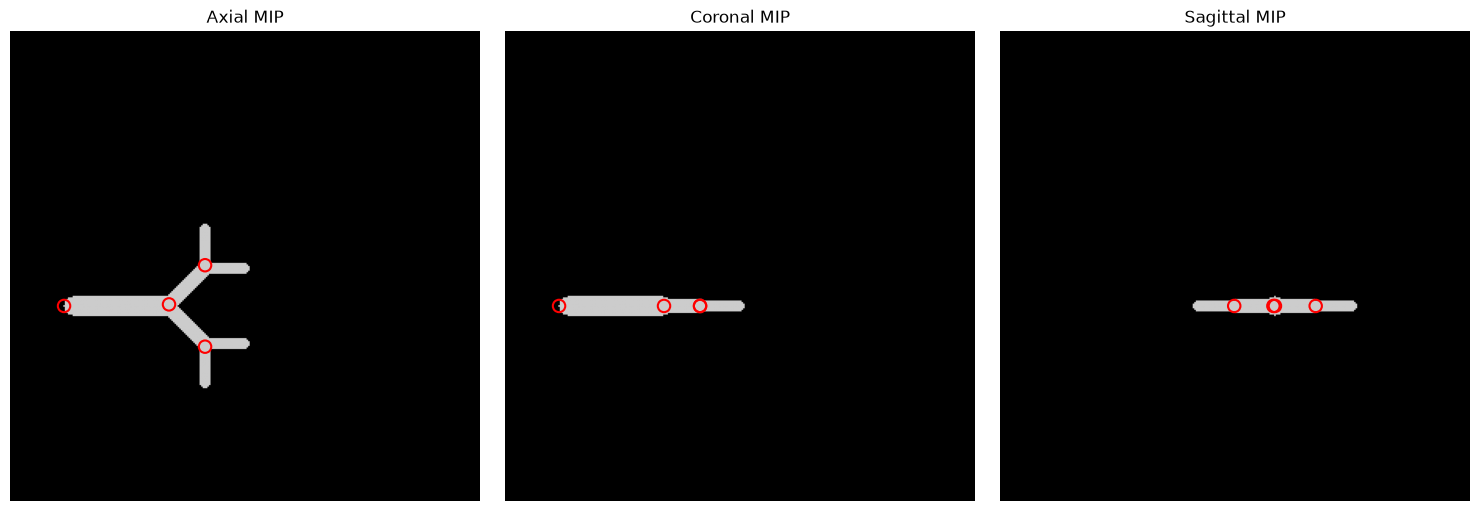

<class 'itk.itkPointSetPython.itkPointSetD3'>


In [17]:
show_mip(aligned, show_points=branch_origins_prediction, cmap='nipy_spectral')
print(type(aligned_points))

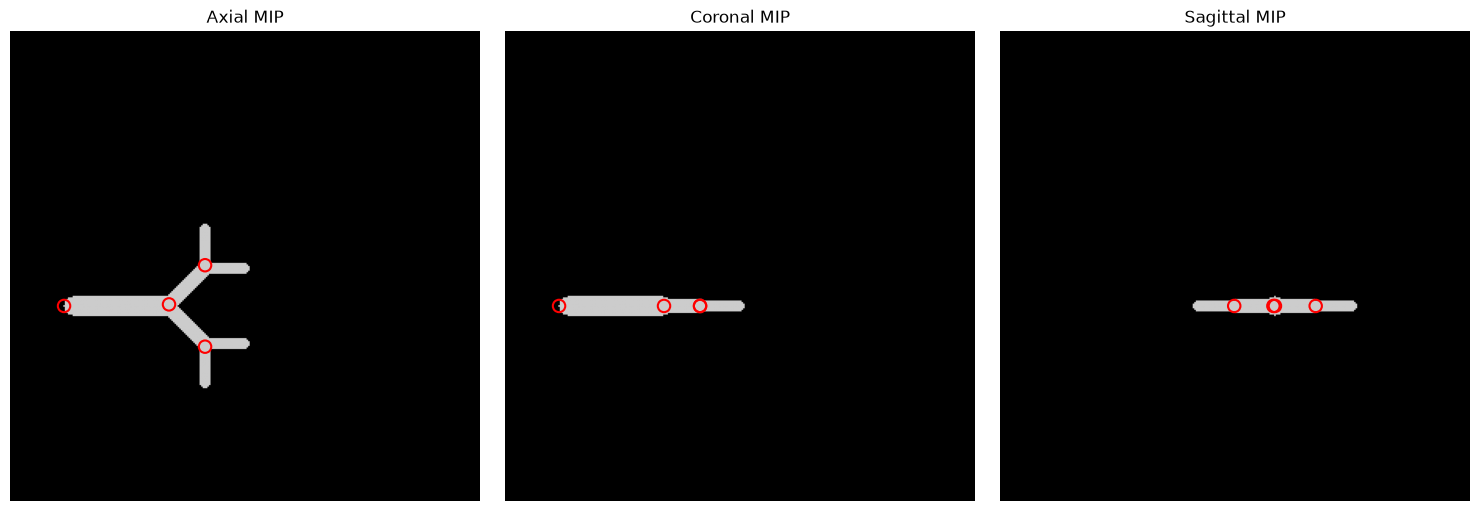

<class 'itk.itkPointSetPython.itkPointSetD3'>


In [18]:
show_mip(aligned, show_points=aligned_points_list, cmap='nipy_spectral')
print(type(aligned_points))

## Skeletonized Resampled

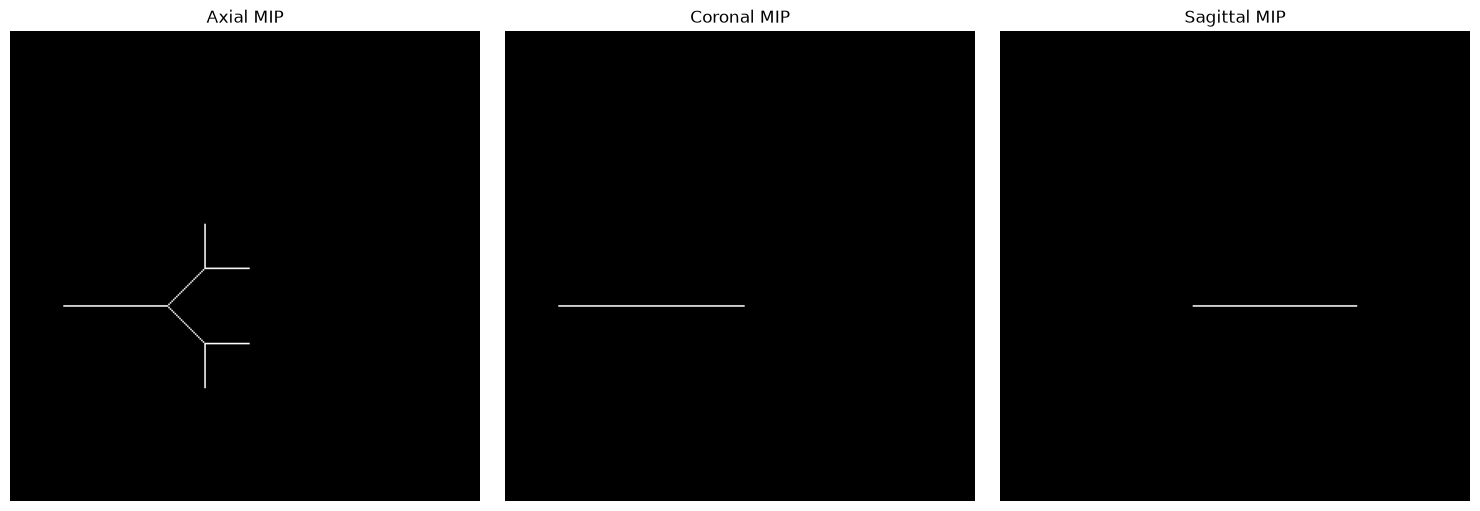

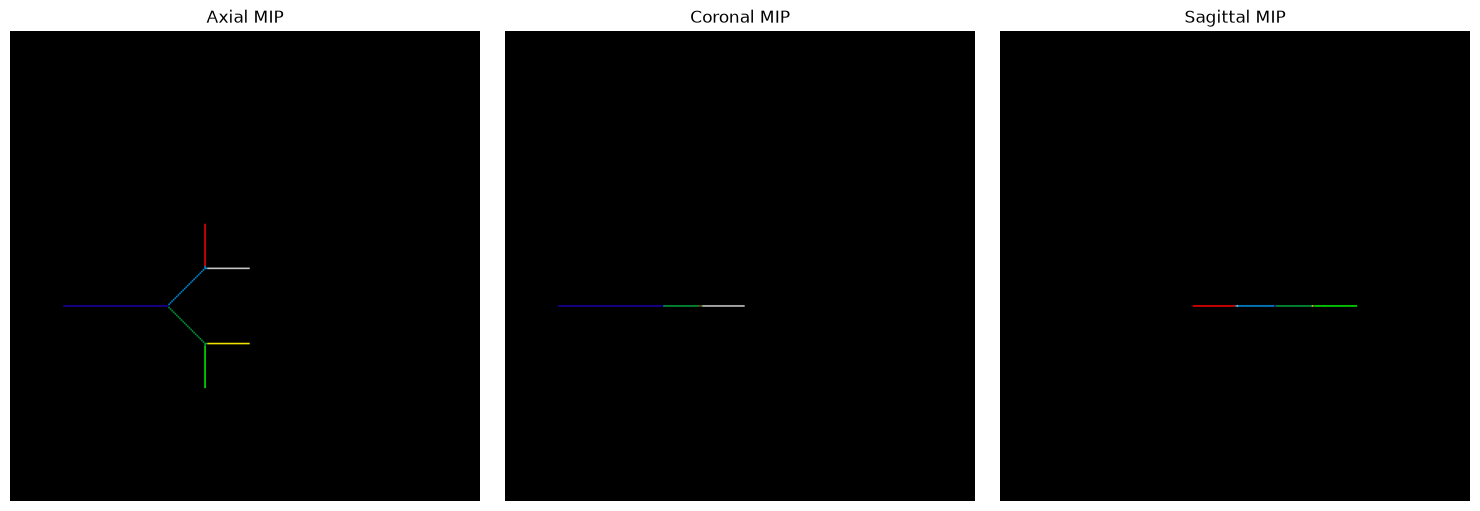

In [19]:
skeletonizeAirwayAligned = SkeletonizeAirwayType.New()
skeletonizeAirwayAligned.SetInput(aligned)
skeletonizeAirwayAligned.Update()
aligned_skeleton = skeletonizeAirwayAligned.GetOutput()
show_mip(aligned_skeleton)

skeletonLabelingAligned = SkeletonLabelingType.New()
skeletonLabelingAligned.SetMaskImage(moving_mask)
skeletonLabelingAligned.SetSkeletonImage(aligned_skeleton)
skeletonLabelingAligned.SetSensitivityMultiplier(1.0)
skeletonLabelingAligned.Update()
show_mip(skeletonLabelingAligned.GetBranchLabelsImage(), cmap='nipy_spectral')

In [20]:
def terminal_nonterminal(image, labeling_class, is_terminal):
    array = itk.array_from_image(image).copy()

    for index in np.ndindex(array.shape):
        value = array[index]

        if value == 0:
            continue

        if labeling_class.IsBranchTerminal(int(value)) != is_terminal:
            array[index] = 0

    output = itk.image_from_array(array)
    output.CopyInformation(image)

    return output

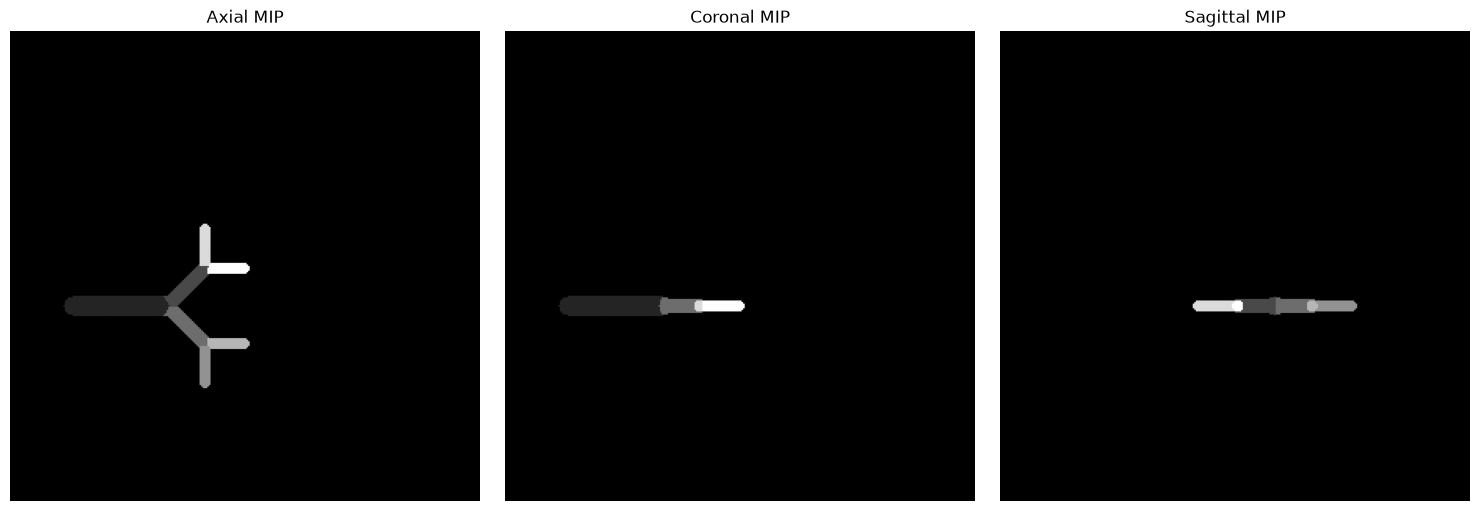

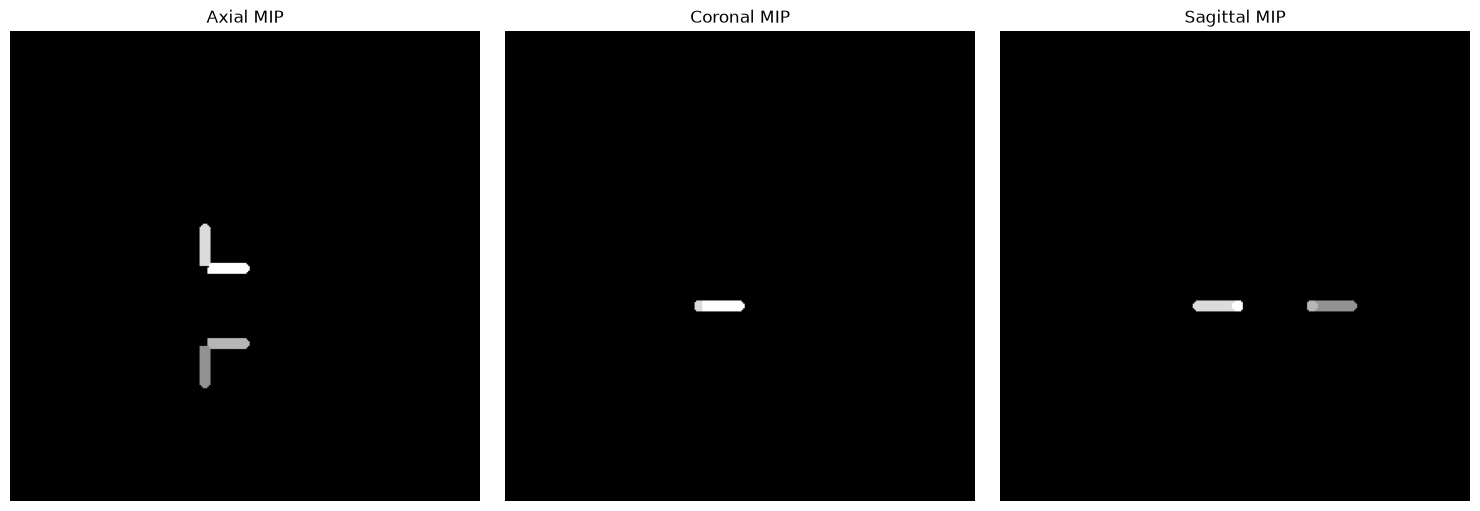

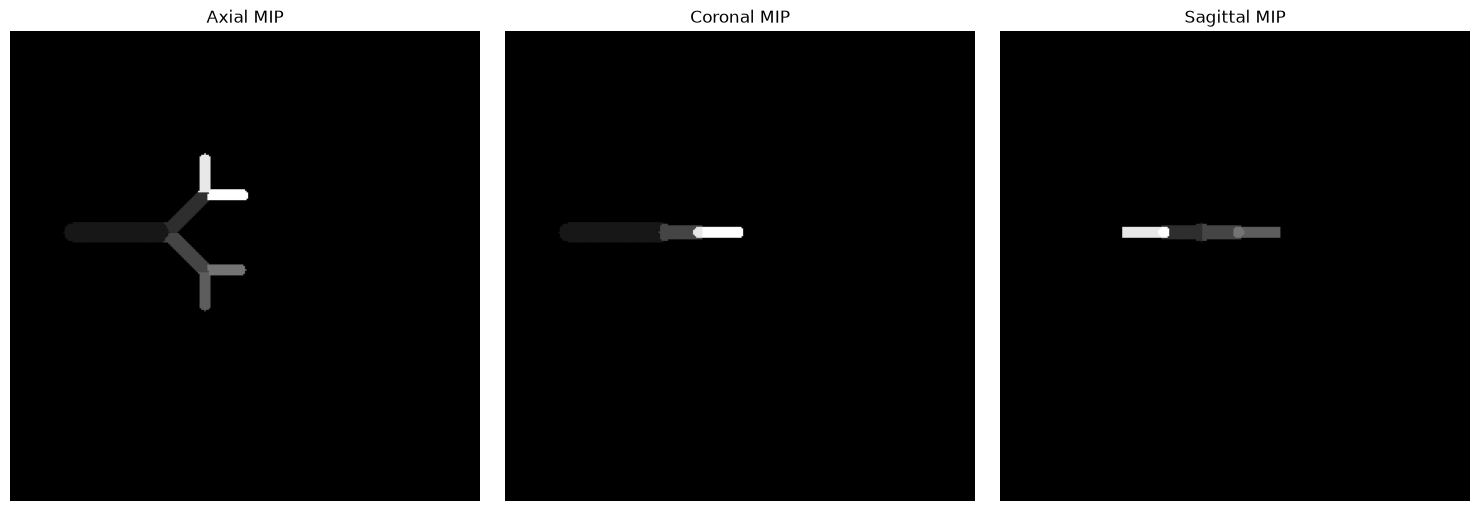

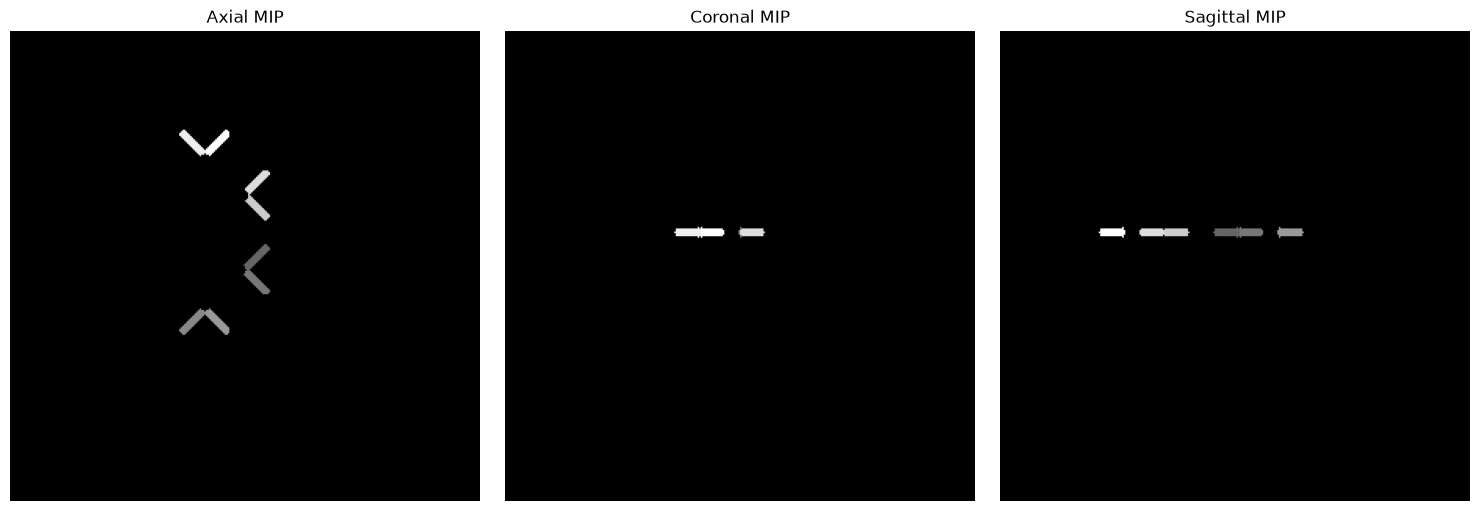

In [21]:
nonterminal_moving = terminal_nonterminal(projectAirwayPrediction.GetBranchLabelsImage(), skeletonLabelingPrediction, False)
show_mip(moving_image)
terminal_moving = terminal_nonterminal(projectAirwayPrediction.GetBranchLabelsImage(), skeletonLabelingPrediction, True)
show_mip(terminal_moving)

nonterminal_fixed = terminal_nonterminal(projectAirwayGroundTruth.GetBranchLabelsImage(), skeletonLabelingGroundTruth, False)
show_mip(nonterminal_fixed)
terminal_fixed = terminal_nonterminal(projectAirwayGroundTruth.GetBranchLabelsImage(), skeletonLabelingGroundTruth, True)
show_mip(terminal_fixed)

## Branch Point Pairing

In [22]:
fixed_landmark_ids = skeletonLabelingGroundTruth.GetLandmarks()
moving_landmark_ids = skeletonLabelingPrediction.GetLandmarks()

# -------------------------------------------------------------------------
# Build KD-tree from transformed moving landmarks.
# -------------------------------------------------------------------------

MeasurementVectorType = itk.Vector[itk.F, Dimension]
SampleType = itk.ListSample[MeasurementVectorType]

sample = SampleType.New()
sample.SetMeasurementVectorSize(Dimension)

for moving_id in range(aligned_points.GetNumberOfPoints()):
    point = aligned_points.GetPoint(moving_id)

    measurement = MeasurementVectorType()
    measurement[0] = point[0]
    measurement[1] = point[1]
    measurement[2] = point[2]

    sample.PushBack(measurement)

KdTreeGeneratorType = itk.KdTreeGenerator[SampleType]

generator = KdTreeGeneratorType.New()
generator.SetSample(sample)
generator.SetBucketSize(16)
generator.Update()

kd_tree = generator.GetOutput()

# -------------------------------------------------------------------------
# Find nearest transformed moving landmark for each fixed landmark.
#
# pairs:
#   fixed point index
#   moving point index
#   distance
# -------------------------------------------------------------------------

pairs = []

for fixed_id in range(fixed_points.GetNumberOfPoints()):
    fixed_point = fixed_points.GetPoint(fixed_id)

    query = MeasurementVectorType()
    query[0] = fixed_point[0]
    query[1] = fixed_point[1]
    query[2] = fixed_point[2]

    neighbor_ids = itk.vectorUL()
    neighbor_distances = itk.vectorD()

    kd_tree.Search(
        query,
        1,
        neighbor_ids,
        neighbor_distances
    )

    moving_id = neighbor_ids[0]
    distance = neighbor_distances[0]

    pairs.append(
        (fixed_id, moving_id, distance)
    )

# -------------------------------------------------------------------------
# Convert point indices to branch IDs.
# -------------------------------------------------------------------------

branch_pairs = []

for fixed_id, moving_id, distance in pairs:
    fixed_branch_id = fixed_landmark_ids[fixed_id]
    moving_branch_id = moving_landmark_ids[moving_id]

    branch_pairs.append(
        (fixed_branch_id, moving_branch_id, distance)
    )

# -------------------------------------------------------------------------
# Print branch correspondences.
# -------------------------------------------------------------------------

for fixed_branch_id, moving_branch_id, distance in branch_pairs:
    print(
        "Fixed branch",
        fixed_branch_id,
        "<-> Moving branch",
        moving_branch_id,
        f"({distance:.3f} mm)"
    )

# -------------------------------------------------------------------------
# Reorder transformed moving points into fixed-point order.
# -------------------------------------------------------------------------

PointSetType = type(aligned_points)
reordered_moving = PointSetType.New()

for fixed_id, moving_id, distance in pairs:
    reordered_moving.SetPoint(
        fixed_id,
        aligned_points.GetPoint(moving_id)
    )

Fixed branch 1 <-> Moving branch 1 (66.468 mm)
Fixed branch 2 <-> Moving branch 6 (56.763 mm)
Fixed branch 4 <-> Moving branch 6 (47.265 mm)
Fixed branch 6 <-> Moving branch 6 (53.749 mm)
Fixed branch 8 <-> Moving branch 2 (52.048 mm)
Fixed branch 10 <-> Moving branch 6 (66.468 mm)
Fixed branch 12 <-> Moving branch 6 (69.188 mm)
Fixed branch 14 <-> Moving branch 6 (85.153 mm)


## TPS Registration with Nonterminal Images, Should be unaffected by excess terminal landmarks

In [23]:
thin_plate_spline = itk.ThinPlateSplineKernelTransform[
    itk.D, Dimension
].New()

source = thin_plate_spline.GetSourceLandmarks()
target = thin_plate_spline.GetTargetLandmarks()

# Source = RAW moving origins (paired to fixed), so the TPS maps raw moving
# space -> fixed space; its affine part absorbs the rigid alignment.
for fixed_id, moving_id, distance in pairs:
    source.SetPoint(
        fixed_id,
        moving_points.GetPoint(moving_id)
    )

for i in range(fixed_points.GetNumberOfPoints()):
    target.SetPoint(
        i,
        fixed_points.GetPoint(i)
    )

thin_plate_spline.ComputeWMatrix()

In [24]:
# thin_plate_spline maps moving -> fixed; resampling needs fixed -> moving,
# so build the inverse TPS by swapping the landmarks.
tps_inverse = itk.ThinPlateSplineKernelTransform[itk.D, Dimension].New()
tps_inverse.SetSourceLandmarks(thin_plate_spline.GetTargetLandmarks())
tps_inverse.SetTargetLandmarks(thin_plate_spline.GetSourceLandmarks())
tps_inverse.ComputeWMatrix()

deformed_nonterminal_moving = itk.resample_image_filter(
    nonterminal_moving, 
    use_reference_image=True, 
    reference_image=nonterminal_fixed,
    interpolator=itk.NearestNeighborInterpolateImageFunction.New(nonterminal_moving), 
    transform=tps_inverse)

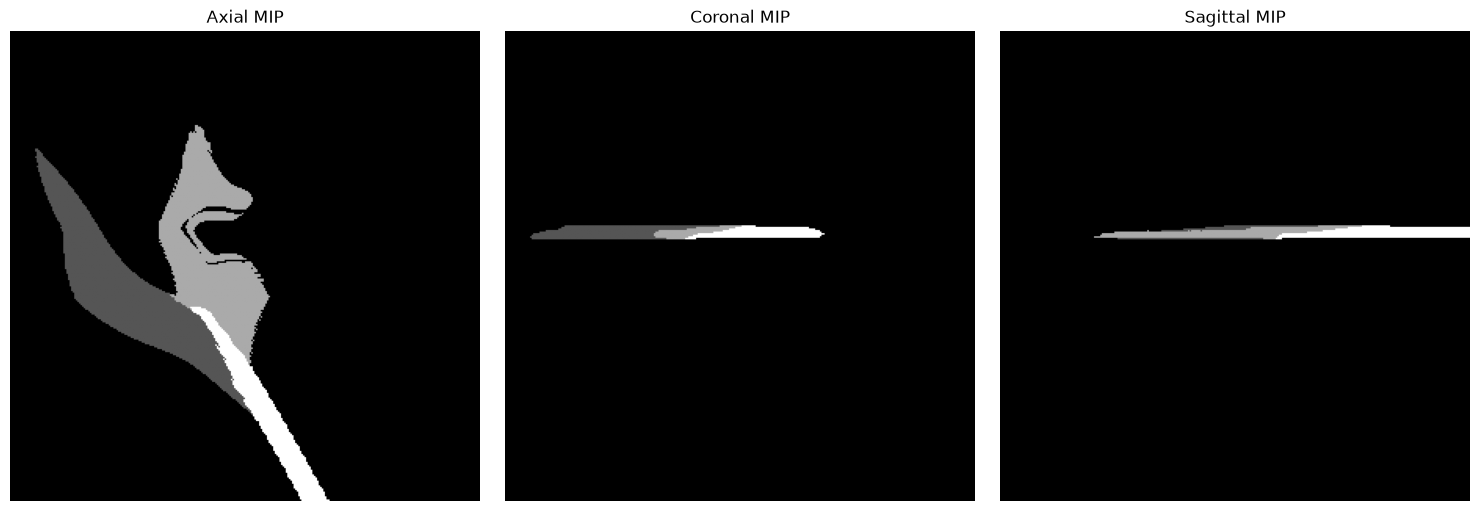

In [25]:
show_mip(deformed_nonterminal_moving)

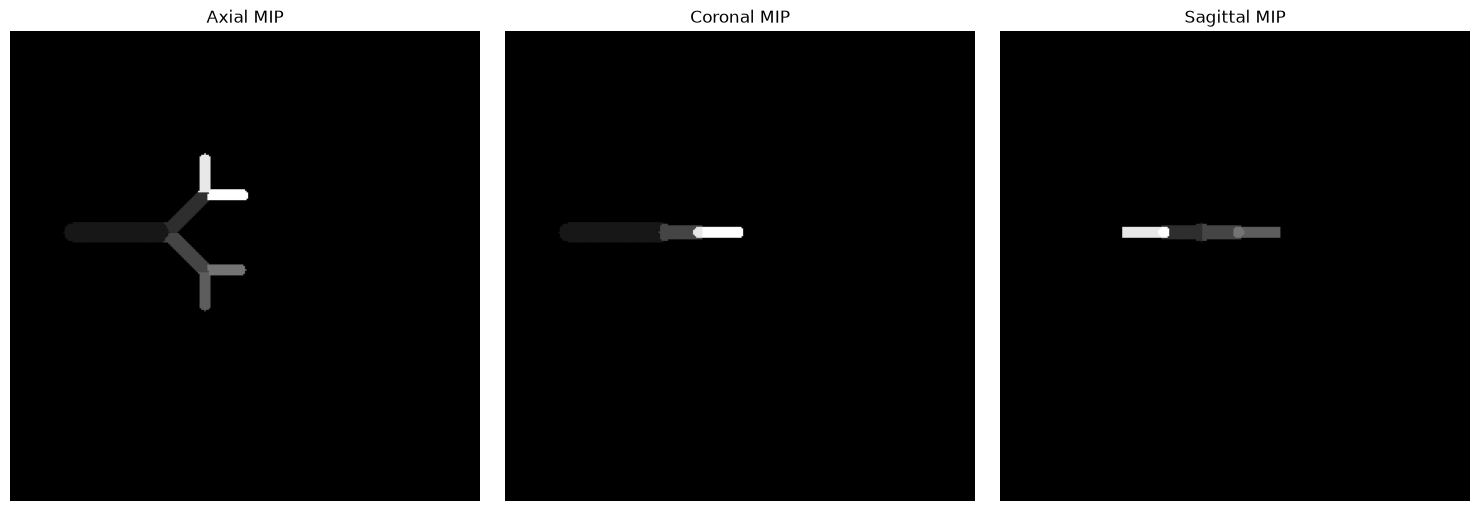

In [26]:
show_mip(nonterminal_fixed)

## Terminal Translation and MSE Rotation

In [27]:
RigidAirwayRegistrationType = itk.RigidAirwayRegistration[LabelImageType]
rigidAirwayRegistration = RigidAirwayRegistrationType.New()
rigidAirwayRegistration.SetFixedImage(terminal_fixed)
rigidAirwayRegistration.SetMovingNonterminalImage(deformed_nonterminal_moving)
rigidAirwayRegistration.SetMovingImage(terminal_moving)
rigidAirwayRegistration.SetNonrigidTransform(thin_plate_spline)
# every branch origin with its label as point data (siblings share an origin)
rigidAirwayRegistration.SetMovingBranchOrigins(skeletonLabelingPrediction.GetBranchOriginPointSet())
rigidAirwayRegistration.Update()

final_aligned_image = rigidAirwayRegistration.GetOutput()

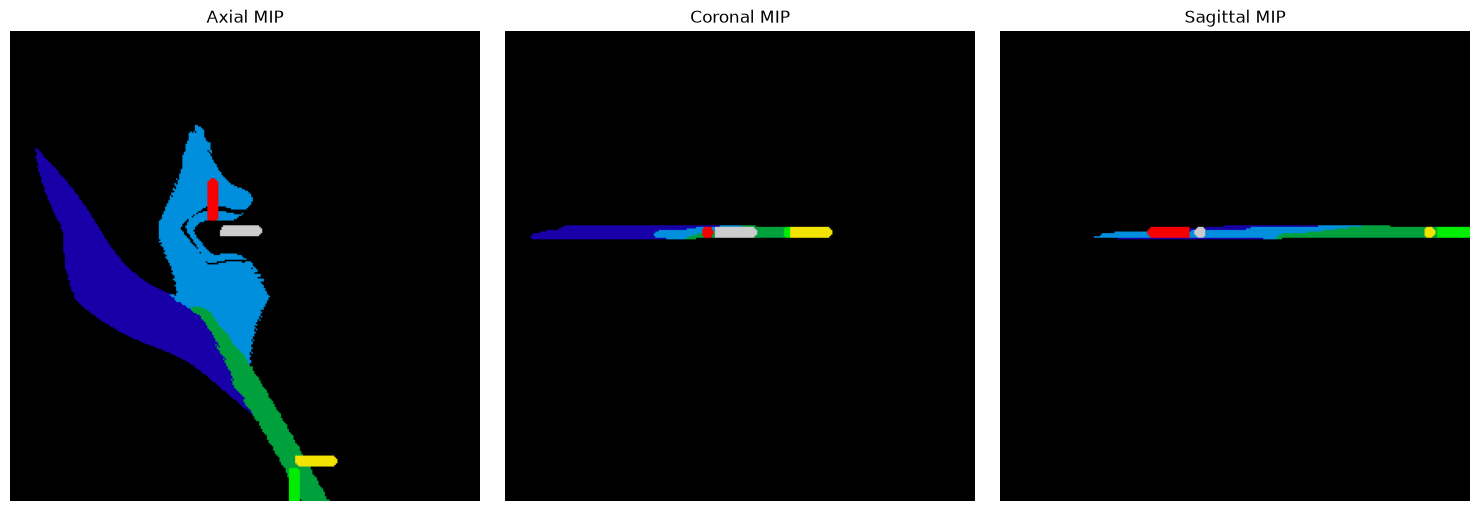

In [28]:
show_mip(final_aligned_image, cmap='nipy_spectral')